In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from itertools import product
from tqdm import trange
import tikzplotlib
from pathlib import Path

from cw.filters import smooth_signal

from cliff_walking.environment import Environment
from cliff_walking.sarsa_agent import SarsaAgent
from cliff_walking.ql_agent import QLearningAgent

In [2]:
environment = Environment((12, 4))

In [3]:
n_agents = 100
n_episodes = 500

s_agents = [SarsaAgent(alpha=0.5, gamma=1, eps=.1, environment=environment) for i in range(n_agents)]
s_rs = [0.0] * n_episodes
q_agents = [QLearningAgent(alpha=0.5, gamma=1, eps=.1, environment=environment) for i in range(n_agents)]
q_rs = [0.0] * n_episodes

for episode_idx in trange(n_episodes):
    for s_agent, q_agent in zip(s_agents, q_agents):        
        s_rs[episode_idx] += s_agent.run(100000) / n_agents
        q_rs[episode_idx] += q_agent.run(100000) / n_agents

100%|██████████| 500/500 [01:23<00:00,  5.97it/s]


<Figure size 1500x600 with 0 Axes>

Text(0.5, 0, 'Episode')

Text(0, 0.5, 'Average sum of rewards')

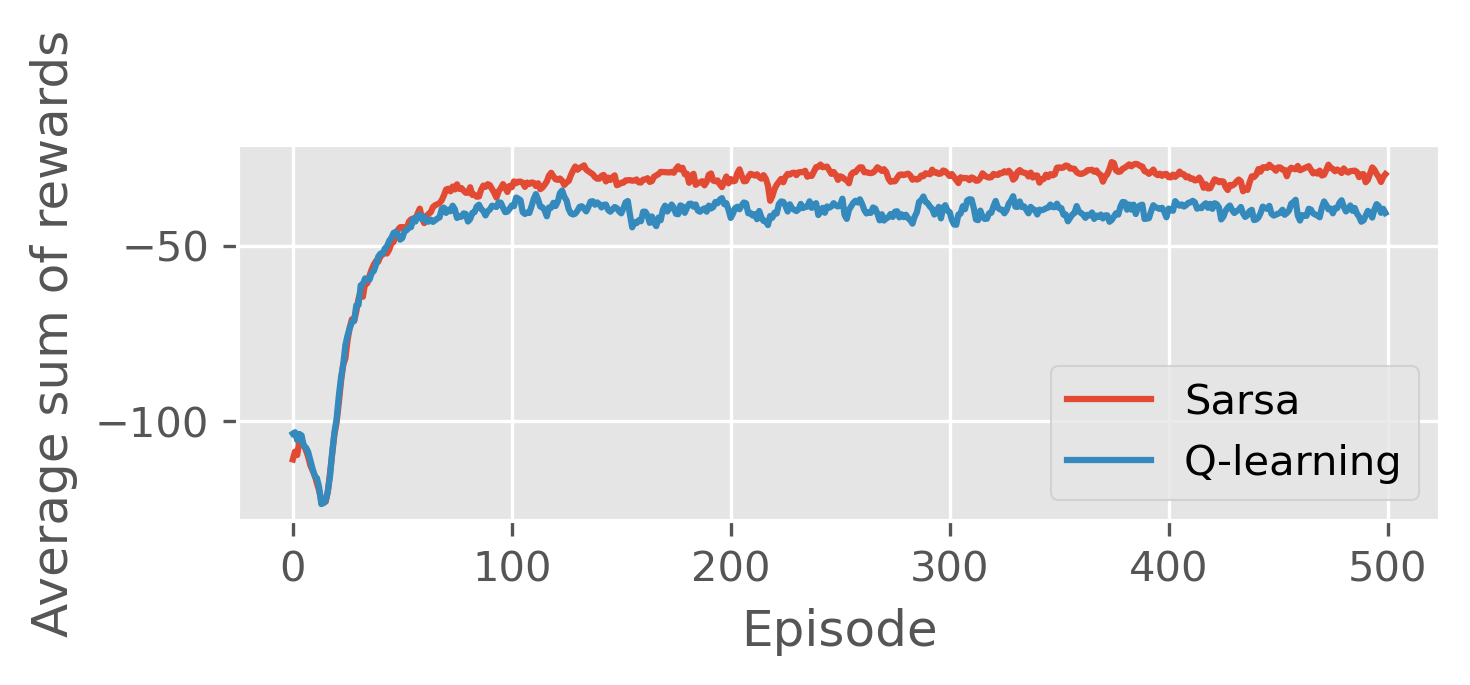

In [10]:
plt.style.use("ggplot")

plt.figure(num=None, figsize=(5, 2), dpi=300, facecolor='w', edgecolor='k')
plt.plot(smooth_signal(s_rs, "exp", weight=0.3), label="Sarsa")
plt.plot(smooth_signal(q_rs, "exp", weight=0.3), label="Q-learning")
plt.xlabel("Episode")
plt.ylabel("Average sum of rewards")
plt.legend()
plt.tight_layout()
plt.savefig("on_off_policy_results.pdf")

fig_dir_path = Path("./").absolute().parent.parent / "reports" / "preliminary_thesis" / "figures"
tikzplotlib.clean_figure()
tikzplotlib.save(fig_dir_path / "on_off_policy_results.tex", extra_axis_parameters=[
    'width=0.9\\textwidth',
    'height=0.3\\textwidth'
])

In [20]:
sorted(s_agents, key=lambda a: a.total_reward_sum)[-2].print_greedy_policy()

→ → → → → → → → → → → ↓ 
↑ → ↑ ↑ ↑ ↑ → ↓ → ↑ → ↓ 
↑ → ↑ ↑ → ← ↑ ← ↑ ↑ → ↓ 
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ 


In [19]:
sorted(q_agents, key=lambda a: a.total_reward_sum)[-1].print_greedy_policy()

→ → ← ↓ → → → → ↓ → → ↓ 
↓ ↑ → → → → → ↓ ↓ ↓ → ↓ 
→ → → → → → → → → → → ↓ 
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ 


In [15]:
s_rs = [0.0] * n_episodes
q_rs = [0.0] * n_episodes
for episode_idx in trange(n_episodes):
    for s_agent, q_agent in zip(s_agents, q_agents):        
        s_agent.eps = 0.0
        q_agent.eps = 0.0 
        s_rs[episode_idx] += s_agent.run(50) / n_agents
        q_rs[episode_idx] += q_agent.run(50) / n_agents

100%|██████████| 500/500 [00:10<00:00, 48.77it/s]


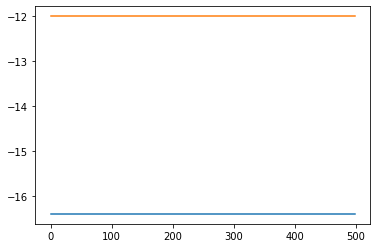

In [16]:
plt.plot(s_rs)
plt.plot(q_rs,)

In [15]:
n_agents = 10
n_episodes = 10000

s_agents = [SarsaAgent(alpha=0.5, gamma=1, eps=.1, environment=environment) for i in range(n_agents)]
s_rs = [0.0] * n_episodes
q_agents = [QLearningAgent(alpha=0.5, gamma=1, eps=.1, environment=environment) for i in range(n_agents)]
q_rs = [0.0] * n_episodes

eps = 0.1

for episode_idx in trange(n_episodes):
    for s_agent, q_agent in zip(s_agents, q_agents):
        if episode_idx > 200:
            s_agent.eps = eps * (1 - episode_idx / n_episodes)
            q_agent.eps = eps * (1 - episode_idx / n_episodes)
        else:
            s_agent.eps = eps
            q_agent.eps = eps
        s_rs[episode_idx] += s_agent.run(100000) / n_agents
        q_rs[episode_idx] += q_agent.run(100000) / n_agents

100%|██████████| 10000/10000 [03:02<00:00, 54.91it/s]


<Figure size 1500x600 with 0 Axes>

Text(0.5, 0, 'Episode')

Text(0, 0.5, 'Average sum of rewards')

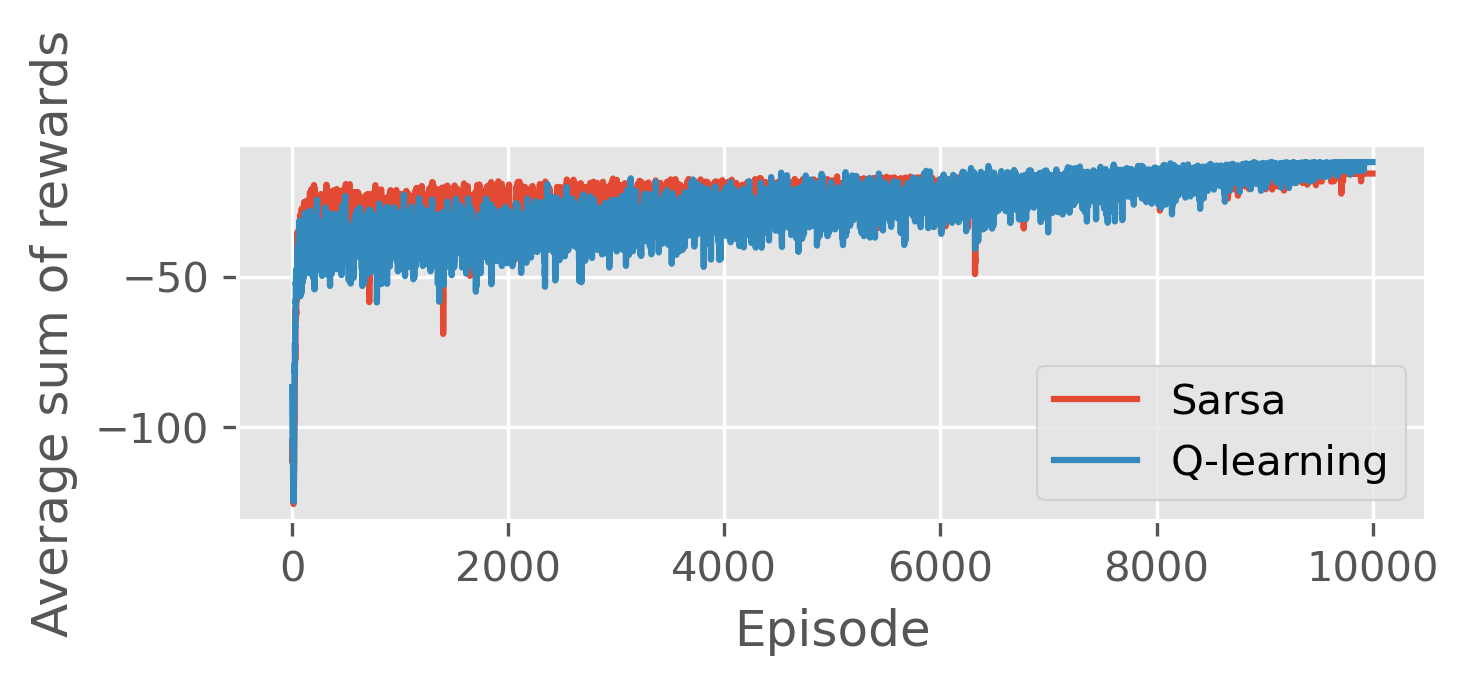

In [16]:
plt.figure(num=None, figsize=(5, 2), dpi=300, facecolor='w', edgecolor='k')
plt.plot(smooth_signal(s_rs, "exp", weight=0.3), label="Sarsa")
plt.plot(smooth_signal(q_rs, "exp", weight=0.3), label="Q-learning")
plt.xlabel("Episode")
plt.ylabel("Average sum of rewards")
plt.legend()
plt.tight_layout()
plt.savefig("on_off_policy_results.pdf")